In [1]:
import pandas as pd
import numpy as np

In [2]:
sales_data = np.array([
    [10, 20, np.nan, 40],
    [5,  np.nan, 15, 20],
    [30, 30, 30, 30],
    [np.nan, 5, 5, 5]
])

# Ціни на кожен з 4-х товарів
prices = np.array([100, 200, 50, 300])


In [25]:

mask = np.isnan(sales_data)
clean_data = np.where(mask, 0, sales_data)


In [4]:

prices = prices.reshape(4,1)# те саме що prices[:, np.newaxis]
clean_data * prices 

array([[1000., 2000.,    0., 4000.],
       [1000.,    0., 3000., 4000.],
       [1500., 1500., 1500., 1500.],
       [   0., 1500., 1500., 1500.]])

In [5]:
col = ['Mon', 'Tue', 'Wed', 'Thu']
index = ['Apple', 'Banana', 'Orange', 'Grape']
df = pd.DataFrame(sales_data, index=index, columns=col)

In [6]:
df

,Mon,Tue,Wed,Thu
Apple,10.0,20.0,NaN,40.0
Banana,5.0,NaN,15.0,20.0
Orange,30.0,30.0,30.0,30.0
Grape,NaN,5.0,5.0,5.0


In [36]:
means = df.mean(axis=1)
print(means)
#Треба транспонувати бо за fillna йде по рядках
result = df.T.fillna(means).T
print(result)
final_res = df[df['Mon']>10]

Apple     23.333333
Banana    13.333333
Orange    30.000000
Grape      5.000000
dtype: float64
         Mon        Tue        Wed   Thu
Apple   10.0  20.000000  23.333333  40.0
Banana   5.0  13.333333  15.000000  20.0
Orange  30.0  30.000000  30.000000  30.0
Grape    5.0   5.000000   5.000000   5.0


In [8]:
# Таблиця з продажами за тиждень (вже почищена тобою)
# Використовуй свій df_filled з попереднього завдання

# Нова таблиця: Дані про постачальників
suppliers = pd.DataFrame({
    'info': ['FruitCo', 'GardenBest', 'FruitCo', 'EcoFarm'],
    'region': ['South', 'North', 'South', 'West']
}, index=['Apple', 'Banana', 'Orange', 'Grape'])

In [9]:
new_df = pd.concat([result, suppliers], axis=1)
new = new_df.groupby('region')['Mon'].sum()
new


region
North     5.0
South    40.0
West      5.0
Name: Mon, dtype: float64

In [46]:
region = suppliers['region']
arr_reg = np.array(region)
print(arr_reg)
mask = (arr_reg == 'South')
print(mask)
tax = np.where(arr_reg == 'South', 0.5, 0.1)
tax_col = tax.reshape(-1,1)
tax_col.shape
print(np.concat((result, tax_col),axis=1))#просто зєднує стовпці 
with_tax = result * tax_col
with_tax

['South' 'North' 'South' 'West']
[ True False  True False]
[[10.         20.         23.33333333 40.          0.5       ]
 [ 5.         13.33333333 15.         20.          0.1       ]
 [30.         30.         30.         30.          0.5       ]
 [ 5.          5.          5.          5.          0.1       ]]


,Mon,Tue,Wed,Thu
Apple,5.0,10.000000,11.666667,20.0
Banana,0.5,1.333333,1.500000,2.0
Orange,15.0,15.000000,15.000000,15.0
Grape,0.5,0.500000,0.500000,0.5


Аномалії

In [47]:
import pandas as pd
import numpy as np

df_dirty = pd.DataFrame({
    'product': [' apple', 'Apple ', 'APPLE', 'banana', ' Banana', 'ORANGE'],
    'sales': [10, 15, 10, 20, 25, 50]
})

In [80]:

df_dirty['product'] = df_dirty['product'].str.strip().str.lower()
df_clean = df_dirty
df_clean.groupby(df_clean['product']).sum()
df_clean['status'] = np.where(df_clean['sales'] > 30, 'High', 'Low')
df_clean


,product,sales,status
0,apple,10,Low
1,apple,15,Low
2,apple,10,Low
3,banana,20,Low
4,banana,25,Low
5,orange,50,High


In [81]:
import pandas as pd
import numpy as np

# Дані про замовлення
orders = pd.DataFrame({
    'order_id': np.arange(100, 110),
    'quantity': [1, 5, 2, 10, 1, 8, 3, 4, 12, 2],
    'unit_price': [100, 50, 150, 40, 200, 30, 80, 90, 25, 110]
})


In [88]:
orders['totatal_cost'] = orders['quantity'] * orders['unit_price']
mean = orders['totatal_cost'].mean()
std = orders['totatal_cost'].std()
mask = (orders['totatal_cost'] > (mean+std))

In [89]:
orders['outliers'] = np.where(mask, True, False)

In [90]:
print(orders)

   order_id  quantity  unit_price  totatal_cost  outliers
0       100         1         100           100     False
1       101         5          50           250     False
2       102         2         150           300     False
3       103        10          40           400      True
4       104         1         200           200     False
5       105         8          30           240     False
6       106         3          80           240     False
7       107         4          90           360      True
8       108        12          25           300     False
9       109         2         110           220     False


In [95]:

labels = ['Cheap', 'Medium', 'Expensive']
orders['price_cat'] = pd.cut(orders['totatal_cost'], bins=3, labels=labels)
orders

,order_id,quantity,unit_price,totatal_cost,outliers,price_cat
0,100,1,100,100,False,Cheap
1,101,5,50,250,False,Medium
2,102,2,150,300,False,Medium
3,103,10,40,400,True,Expensive
4,104,1,200,200,False,Cheap
5,105,8,30,240,False,Medium
6,106,3,80,240,False,Medium
7,107,4,90,360,True,Expensive
8,108,12,25,300,False,Medium
9,109,2,110,220,False,Medium


In [2]:
import pandas as pd
import numpy as np

# 1. Транзакції (1000 записів)
np.random.seed(42)
dates = pd.date_range(start='2026-01-01', periods=100, freq='D')
items = ['Tech', 'Fashion', 'Home']

df_sales = pd.DataFrame({
    'date': np.random.choice(dates, 1000),
    'category': np.random.choice(items, 1000),
    'revenue': np.random.uniform(10, 500, 1000)
})

# Додамо трохи "бруду" - пропуски в виручці
df_sales.loc[np.random.choice(1000, 50), 'revenue'] = np.nan

# 2. Витрати на маркетинг
df_marketing = pd.DataFrame({
    'date': dates,
    'spend': np.random.uniform(50, 200, 100)
})

In [94]:
median = np.nanmedian(df_sales['revenue'])

mask = np.isnan(df_sales['revenue'])
revenue_null_mediana = np.where(mask, median, df_sales['revenue'])
df_sales['revenue'] = revenue_null_mediana

In [107]:
mean = np.mean(revenue_null_mediana)
std = np.std(revenue_null_mediana)
cool_rev = mean + (std*2)
mask = revenue_null_mediana > cool_rev 
df_sales[df_sales['revenue'] > cool_rev]

,date,category,revenue


In [108]:
daily_sales = df_sales.groupby('date')['revenue'].sum().reset_index()

In [109]:
new_df = pd.merge(df_sales, df_marketing, on='date', how='left')

In [110]:
new_df

,date,category,revenue,spend
0,2026-02-21,Fashion,261.163563,107.635943
1,2026-04-03,Home,357.439655,109.315140
2,2026-01-15,Tech,436.774871,98.162165
3,2026-03-13,Home,359.902597,51.006559
4,2026-03-02,Fashion,402.846761,108.946134
...,...,...,...,...
995,2026-01-10,Tech,62.932620,63.842719
996,2026-03-08,Fashion,176.041718,164.286023
997,2026-01-18,Tech,403.266983,146.914426
998,2026-04-10,Home,290.303835,106.220535


In [112]:
profit = new_df['revenue'] - new_df['spend']
ROI_ReturnOnInvestment = profit/new_df['spend'] * 100
Succsesful_sales = np.where(100 < ROI_ReturnOnInvestment, 'Good', 'Bad')
new_df['profit'] = Succsesful_sales

performance = new_df[['date', 'profit']]
performance.set_index('date', inplace=True)
performance_daily = performance.groupby('date').first()
week_report = performance_daily.resample('W').asfreq()
print(week_report)

           profit
date             
2026-01-04   Good
2026-01-11   Good
2026-01-18   Good
2026-01-25   Good
2026-02-01    Bad
2026-02-08    Bad
2026-02-15   Good
2026-02-22    Bad
2026-03-01   Good
2026-03-08    Bad
2026-03-15   Good
2026-03-22    Bad
2026-03-29   Good
2026-04-05    Bad
2026-04-12    NaN


In [3]:
import numpy as np

# Студенти та їхні курси
students = pd.DataFrame({
    'st_id': [1, 2, 3, 4, 5],
    'name': ['Alex', 'Olga', 'Ivan', 'Petro', 'Anna'],
    'course': ['Python', 'JS', 'Python', 'JS', 'C++']
})

# Оплати (з дублікатами дат і пропущеними значеннями)
payments = pd.DataFrame({
    'st_id': [1, 1, 2, 3, 4, 5, 1],
    'date': ['2026-03-01', '2026-03-01', '2026-03-02', '2026-03-05', '2026-03-10', '2026-03-12', '2026-03-15'],
    'amount': [500, np.nan, 450, 700, 300, np.nan, 550]
})


In [25]:
min_val = np.nanmin(payments['amount'])
payments['amount'] = np.where(np.isnan(payments['amount']), min_val, payments['amount'])
concated_table = pd.merge(students,payments, on='st_id', how='left')
agregated = concated_table.groupby('course')['amount'].sum()

In [26]:
concated_table['date']=pd.to_datetime(concated_table['date'])
concated_table.groupby('date').sum().resample('W').sum()

,st_id,name,course,amount
date,,,,
2026-03-01,2,AlexAlex,PythonPython,800.0
2026-03-08,5,OlgaIvan,JSPython,1150.0
2026-03-15,10,PetroAnnaAlex,JSC++Python,1150.0


In [1]:
import pandas as pd
import numpy as np

In [2]:
sales_data = np.array([
    [10, 20, np.nan, 40],
    [5,  np.nan, 15, 20],
    [30, 30, 30, 30],
    [np.nan, 5, 5, 5]
])

# Ціни на кожен з 4-х товарів
prices = np.array([100, 200, 50, 300])


In [25]:

mask = np.isnan(sales_data)
clean_data = np.where(mask, 0, sales_data)


In [4]:

prices = prices.reshape(4,1)# те саме що prices[:, np.newaxis]
clean_data * prices 

array([[1000., 2000.,    0., 4000.],
       [1000.,    0., 3000., 4000.],
       [1500., 1500., 1500., 1500.],
       [   0., 1500., 1500., 1500.]])

In [5]:
col = ['Mon', 'Tue', 'Wed', 'Thu']
index = ['Apple', 'Banana', 'Orange', 'Grape']
df = pd.DataFrame(sales_data, index=index, columns=col)

In [6]:
df

,Mon,Tue,Wed,Thu
Apple,10.0,20.0,NaN,40.0
Banana,5.0,NaN,15.0,20.0
Orange,30.0,30.0,30.0,30.0
Grape,NaN,5.0,5.0,5.0


In [36]:
means = df.mean(axis=1)
print(means)
#Треба транспонувати бо за fillna йде по рядках
result = df.T.fillna(means).T
print(result)
final_res = df[df['Mon']>10]

Apple     23.333333
Banana    13.333333
Orange    30.000000
Grape      5.000000
dtype: float64
         Mon        Tue        Wed   Thu
Apple   10.0  20.000000  23.333333  40.0
Banana   5.0  13.333333  15.000000  20.0
Orange  30.0  30.000000  30.000000  30.0
Grape    5.0   5.000000   5.000000   5.0


In [8]:
# Таблиця з продажами за тиждень (вже почищена тобою)
# Використовуй свій df_filled з попереднього завдання

# Нова таблиця: Дані про постачальників
suppliers = pd.DataFrame({
    'info': ['FruitCo', 'GardenBest', 'FruitCo', 'EcoFarm'],
    'region': ['South', 'North', 'South', 'West']
}, index=['Apple', 'Banana', 'Orange', 'Grape'])

In [9]:
new_df = pd.concat([result, suppliers], axis=1)
new = new_df.groupby('region')['Mon'].sum()
new


region
North     5.0
South    40.0
West      5.0
Name: Mon, dtype: float64

In [46]:
region = suppliers['region']
arr_reg = np.array(region)
print(arr_reg)
mask = (arr_reg == 'South')
print(mask)
tax = np.where(arr_reg == 'South', 0.5, 0.1)
tax_col = tax.reshape(-1,1)
tax_col.shape
print(np.concat((result, tax_col),axis=1))#просто зєднує стовпці 
with_tax = result * tax_col
with_tax

['South' 'North' 'South' 'West']
[ True False  True False]
[[10.         20.         23.33333333 40.          0.5       ]
 [ 5.         13.33333333 15.         20.          0.1       ]
 [30.         30.         30.         30.          0.5       ]
 [ 5.          5.          5.          5.          0.1       ]]


,Mon,Tue,Wed,Thu
Apple,5.0,10.000000,11.666667,20.0
Banana,0.5,1.333333,1.500000,2.0
Orange,15.0,15.000000,15.000000,15.0
Grape,0.5,0.500000,0.500000,0.5


Аномалії

In [47]:
import pandas as pd
import numpy as np

df_dirty = pd.DataFrame({
    'product': [' apple', 'Apple ', 'APPLE', 'banana', ' Banana', 'ORANGE'],
    'sales': [10, 15, 10, 20, 25, 50]
})

In [80]:

df_dirty['product'] = df_dirty['product'].str.strip().str.lower()
df_clean = df_dirty
df_clean.groupby(df_clean['product']).sum()
df_clean['status'] = np.where(df_clean['sales'] > 30, 'High', 'Low')
df_clean


,product,sales,status
0,apple,10,Low
1,apple,15,Low
2,apple,10,Low
3,banana,20,Low
4,banana,25,Low
5,orange,50,High


In [81]:
import pandas as pd
import numpy as np

# Дані про замовлення
orders = pd.DataFrame({
    'order_id': np.arange(100, 110),
    'quantity': [1, 5, 2, 10, 1, 8, 3, 4, 12, 2],
    'unit_price': [100, 50, 150, 40, 200, 30, 80, 90, 25, 110]
})


In [88]:
orders['totatal_cost'] = orders['quantity'] * orders['unit_price']
mean = orders['totatal_cost'].mean()
std = orders['totatal_cost'].std()
mask = (orders['totatal_cost'] > (mean+std))

In [89]:
orders['outliers'] = np.where(mask, True, False)

In [90]:
print(orders)

   order_id  quantity  unit_price  totatal_cost  outliers
0       100         1         100           100     False
1       101         5          50           250     False
2       102         2         150           300     False
3       103        10          40           400      True
4       104         1         200           200     False
5       105         8          30           240     False
6       106         3          80           240     False
7       107         4          90           360      True
8       108        12          25           300     False
9       109         2         110           220     False


In [95]:

labels = ['Cheap', 'Medium', 'Expensive']
orders['price_cat'] = pd.cut(orders['totatal_cost'], bins=3, labels=labels)
orders

,order_id,quantity,unit_price,totatal_cost,outliers,price_cat
0,100,1,100,100,False,Cheap
1,101,5,50,250,False,Medium
2,102,2,150,300,False,Medium
3,103,10,40,400,True,Expensive
4,104,1,200,200,False,Cheap
5,105,8,30,240,False,Medium
6,106,3,80,240,False,Medium
7,107,4,90,360,True,Expensive
8,108,12,25,300,False,Medium
9,109,2,110,220,False,Medium


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt# Створюємо 100 дат (як рядки, бо так вони зазвичай приходять з CSV)
dates = pd.date_range(start='2026-01-01', periods=100).astype(str)

# Створюємо масив продажів із випадковими пропусками (NaN)
np.random.seed(42)
sales_values = np.random.randint(100, 1000, size=100).astype(float)
sales_values[np.random.choice(100, 10, replace=False)] = np.nan

df = pd.DataFrame({
    'date_str': dates,
    'sales': sales_values
})
df

,date_str,sales
0,2026-01-01,202.0
1,2026-01-02,535.0
2,2026-01-03,960.0
3,2026-01-04,370.0
4,2026-01-05,206.0
...,...,...
95,2026-04-06,301.0
96,2026-04-07,369.0
97,2026-04-08,962.0
98,2026-04-09,915.0


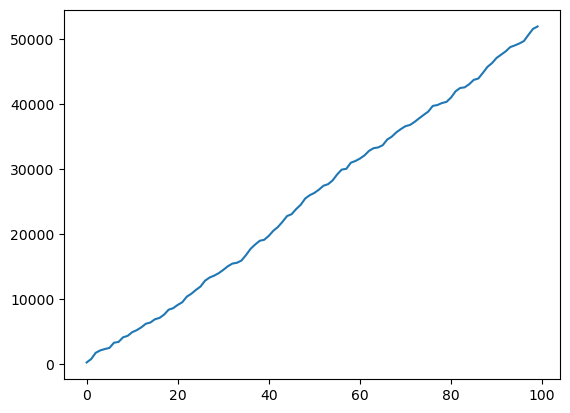

In [27]:
sales_value_new = sales_values.copy()

median = np.nanmedian(sales_value_new)
sales_value_new = np.where(np.isnan(sales_value_new), median, sales_value_new) 
cumul_sum = np.cumsum(sales_value_new)
plt.plot(cumul_sum)


In [63]:
df['date_str'] = pd.to_datetime(df['date_str'])
df['day_name'] = df['date_str'].dt.day_name()
Sat = df[df['day_name'] == 'Saturday']
Sun = df[df['day_name'] == 'Sunday']
df = pd.concat([Sat,Sun], axis=0)
df[df['sales'] > 500]

,date_str,sales,day_name
2,2026-01-03,960.0,Saturday
37,2026-02-07,660.0,Saturday
44,2026-02-14,882.0,Saturday
58,2026-02-28,940.0,Saturday
93,2026-04-04,655.0,Saturday
10,2026-01-11,566.0,Sunday
24,2026-01-25,591.0,Sunday
31,2026-02-01,559.0,Sunday
38,2026-02-08,574.0,Sunday
52,2026-02-22,604.0,Sunday


In [1]:
import pandas as pd
import numpy as np

In [2]:
sales_data = np.array([
    [10, 20, np.nan, 40],
    [5,  np.nan, 15, 20],
    [30, 30, 30, 30],
    [np.nan, 5, 5, 5]
])

# Ціни на кожен з 4-х товарів
prices = np.array([100, 200, 50, 300])


In [18]:

mask = np.isnan(sales_data)
clean_data = np.where(mask, 0, sales_data)


In [24]:

prices = prices.reshape(4,1)# те саме що prices[:, np.newaxis]
clean_data * prices 

array([[1000., 2000.,    0., 4000.],
       [1000.,    0., 3000., 4000.],
       [1500., 1500., 1500., 1500.],
       [   0., 1500., 1500., 1500.]])

In [26]:
col = ['Mon', 'Tue', 'Wed', 'Thu']
index = ['Apple', 'Banana', 'Orange', 'Grape']
df = pd.DataFrame(sales_data, index=index, columns=col)

In [27]:
df

,Mon,Tue,Wed,Thu
Apple,10.0,20.0,NaN,40.0
Banana,5.0,NaN,15.0,20.0
Orange,30.0,30.0,30.0,30.0
Grape,NaN,5.0,5.0,5.0


In [40]:
means = df.mean(axis=1)
print(means)
#Треба транспонувати бо за fillna йде по рядках
result = df.T.fillna(means).T
print(result)
final_res = df[df['Mon']>10]

Apple     23.333333
Banana    13.333333
Orange    30.000000
Grape      5.000000
dtype: float64
         Mon        Tue        Wed   Thu
Apple   10.0  20.000000  23.333333  40.0
Banana   5.0  13.333333  15.000000  20.0
Orange  30.0  30.000000  30.000000  30.0
Grape    5.0   5.000000   5.000000   5.0


In [42]:
# Таблиця з продажами за тиждень (вже почищена тобою)
# Використовуй свій df_filled з попереднього завдання

# Нова таблиця: Дані про постачальників
suppliers = pd.DataFrame({
    'info': ['FruitCo', 'GardenBest', 'FruitCo', 'EcoFarm'],
    'region': ['South', 'North', 'South', 'West']
}, index=['Apple', 'Banana', 'Orange', 'Grape'])

In [52]:
new_df = pd.concat([result, suppliers], axis=1)
new = new_df.groupby('region')['Mon'].sum()
new


region
North     5.0
South    40.0
West      5.0
Name: Mon, dtype: float64